In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# notebook は EXP020/notebook/ にあるので親2つ上がプロジェクトルート
ROOT = Path().resolve().parents[1]
print(f'Project root: {ROOT}')

Project root: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History


In [2]:
# ---- 設定 ----------------------------------------------------------------
bank_id   = 1
prior     = 'normal'
gamma     = '0.1'
KEY_STEPS = [10, 20, 30, 40]

exp007_dir = ROOT / 'EXP007' / 'results'
exp017_dir = ROOT / 'EXP017' / 'results'
exp020_dir = ROOT / 'EXP020' / 'results'

mfi     = pd.read_csv(exp007_dir / f'summary_uncor_{bank_id}_MFI.csv')

def load_if_exists(path: Path):
    return pd.read_csv(path) if path.exists() else None

dqn007 = load_if_exists(exp007_dir / f'summary_uncor_{bank_id}_DQN_{prior}_gamma_0.3.csv')
dqn020 = load_if_exists(exp020_dir / f'summary_uncor_{bank_id}_DQN_{prior}_gamma_{gamma}.csv')
dqn017 = load_if_exists(exp017_dir / f'summary_uncor_{bank_id}_DQN_{prior}_gamma_{gamma}.csv')

for name, df in [('MFI', mfi), ('EXP007', dqn007), ('EXP020', dqn020), ('EXP017', dqn017)]:
    print(f'{name:8s}: {"loaded" if df is not None else "NOT FOUND (skipped)"}')

MFI     : loaded
EXP007  : loaded
EXP020  : loaded
EXP017  : loaded


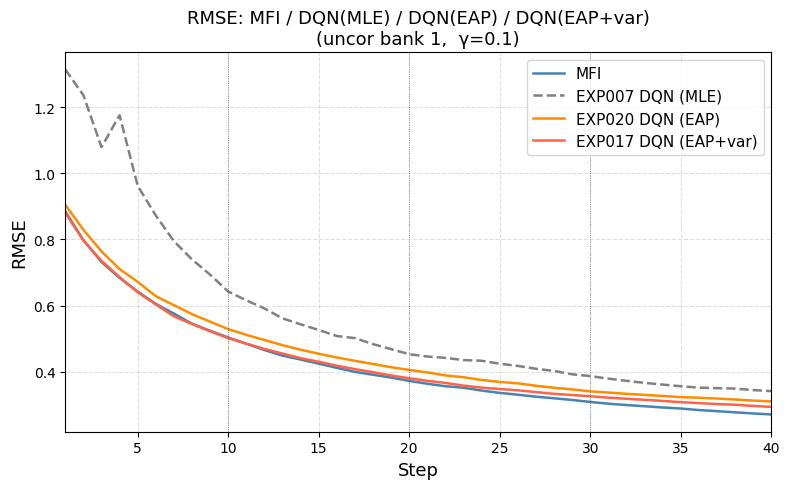

Saved → /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP020/results/rmse_comparison_uncor_1_gamma_0.1.png


In [3]:
# ---- 1枚の図に全系列を重ねてプロット ------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

SERIES = [
    (mfi,    'MFI',                  'steelblue',   '-',  1.8),
    (dqn007, 'EXP007 DQN (MLE)',     'gray',        '--', 1.8),
    (dqn020, 'EXP020 DQN (EAP)',     'darkorange',  '-',  1.8),
    (dqn017, 'EXP017 DQN (EAP+var)', 'tomato',      '-',  1.8),
]

for df, label, color, ls, lw in SERIES:
    if df is not None:
        ax.plot(df['step'], df['RMSE'], label=label, color=color, ls=ls, lw=lw)

for s in KEY_STEPS:
    ax.axvline(s, color='black', lw=0.6, ls=':', alpha=0.5)

ax.set_xlabel('Step', fontsize=13)
ax.set_ylabel('RMSE', fontsize=13)
ax.set_title(
    f'RMSE: MFI / DQN(MLE) / DQN(EAP) / DQN(EAP+var)'
    f'\n(uncor bank {bank_id},  γ={gamma})',
    fontsize=13,
)
ax.legend(fontsize=11)
ax.grid(True, ls='--', alpha=0.4)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.set_xlim(1, 40)

plt.tight_layout()
out_path = exp020_dir / f'rmse_comparison_uncor_{bank_id}_gamma_{gamma}.png'
exp020_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150)
plt.show()
print(f'Saved → {out_path}')

In [4]:
# ---- RMSE 比較テーブル（step 10 / 20 / 30 / 40）----------------------
def rmse_at(df, steps):
    idx = df['step'].round().astype(int)
    return [
        float(df.loc[idx == s, 'RMSE'].values[0])
        if (idx == s).any() else float('nan')
        for s in steps
    ]

rows = []
for name, df in [
    ('MFI',                  mfi),
    ('EXP007 DQN(MLE)',      dqn007),
    ('EXP020 DQN(EAP)',      dqn020),
    ('EXP017 DQN(EAP+var)',  dqn017),
]:
    if df is not None:
        rows.append({'method': name, **dict(zip(KEY_STEPS, rmse_at(df, KEY_STEPS)))})

table = pd.DataFrame(rows).set_index('method')
table.columns.name = 'step'
print(table.to_string(float_format='{:.3f}'.format))

step                   10    20    30    40
method                                     
MFI                 0.504 0.372 0.309 0.271
EXP007 DQN(MLE)     0.643 0.453 0.387 0.342
EXP020 DQN(EAP)     0.529 0.406 0.341 0.310
EXP017 DQN(EAP+var) 0.502 0.380 0.326 0.294
